# Torch-Rechub 新手教程：使用DeepFM进行CTR(点击率)预测

本教程使用 `torch-rechub` 库，以经典的 ML-1M数据集为例，演示从数据读取到模型训练的完整 CTR 预测流程。  
**什么是CTR预测？ (Click-Through Rate Prediction)**  
```text
通俗来说，就是“猜你点不点”，并且给出一个精确的概率。  
字面意思：CTR 的全称是 Click-Through Rate（点击率）。在历史数据中，点击率 = 点击次数 / 展示次数。  
模型层面的意思：这是一个典型的二分类问题（点=1，不点=0）。当你把一个“用户”和一个“商品（或广告）”的信息喂给机器学习模型时，模型会输出一个 0 到 1 之间的小数。   
比如输出 0.85，意思是：模型预测这个用户有 85% 的概率会点击这个广告。  
比如输出 0.01，意思是：模型预测这个用户根本不感兴趣，只有 1% 的可能会点。  
公式化理解： CTR = 预估概率(User, Item, Context)  
（给定这个用户、这个商品、以及当前的上下文环境如时间和地点，求点击的概率）。  
```
**为什么要做CTR预测？**  
```text
在互联网大厂（如字节跳动、阿里、腾讯、Criteo），CTR 预估模型被称为“印钞机”。这主要有以下三个核心原因：  
```
1. 核心商业模式：为了最大化赚钱 (流量变现)  
```text
互联网广告最常见的收费模式是 CPC (Cost Per Click，按点击计费)。也就是说，广告展示出来不收钱，用户点进去了才收钱。  
假设你是一个平台老板，你有两个广告主来竞价：  
广告 A（卖别墅）：点一次老板愿意出价 100元。但因为买得起的人少，模型预测它的 CTR 只有 0.1%。  
广告 B（卖纸巾）：点一次老板只愿意出价 1元。但因为是刚需，模型预测它的 CTR 高达 20%。  
平台该展示哪个才能赚最多？  
展示 A 的期望收益：100元 × 0.1% = 0.1元  
展示 B 的期望收益：1元 × 20% = 0.2元  
结论：展示卖纸巾的广告 B 赚得更多！  
总结：如果没有精准的 CTR 预测，平台就不知道每次展示能赚多少钱。CTR 预测越准，平台赚的钱就越多。  
```
2. 推荐系统的灵魂：为了给内容排序 (Ranking)  
```text
当你打开淘宝、抖音或小红书时，后台的数据库里有千万级别的商品或视频。  
手机屏幕那么小，谁排在第一屏，谁排在后面？  
这时候，系统就会调用 CTR 模型，给候选的几千个商品全部打上“点击概率”的分数，然后按照分数从高到低排序。排在最前面的，就是你一打开手机看到的内容。CTR 模型直接决定了整个推荐系统的展示顺序。  
```
3. 保护用户体验：为了不招人烦  
```text
如果我们只为了赚钱，给用户满屏推劣质的诱导点击广告，用户明天就卸载 App 了。  
精准的 CTR 预测，本质上也是在精准猜测用户的心智和喜好。只给用户推他们真正感兴趣（预测 CTR 高）的内容，既能让商家把东西卖出去，又能让用户刷得开心，实现平台、商家、用户的三赢。  
```
**CTR预测与召回的联系？**
```text
在推荐系统中，CTR 预测经常被用于排序。排序与召回（Recall）是“上下游”的互补关系：
召回（Recall）负责“广度”：
正如我们在 DSSM 模型中看到的，召回的任务是从 1 亿个物品中快速捞出 500 个候选者。它像是一个初审面试官，任务是“别漏掉好苗子”，但它没法对这 500 个人进行非常精细的打分。
排序负责“深度”：
它像是一个主考官，专门负责精挑细选。它只针对召回送来的这 500 个物品，利用更复杂的特征（比如用户历史行为序列的 Attention 机制）进行“毫厘之间”的打分。
```


## 0. 流程总览
我们将遵循以下步骤：
1. **环境设置**：导入所需库并定义全局参数。
2. **数据加载与预处理**：加载 ML-1M 数据集，并将其从评分预测任务转换为二元分类（CTR 预估）任务。
3. **特征工程**：对类别特征进行标签编码（Label Encoding）。
4. **特征封装**：使用 `torch-rechub` 的 `SparseFeature` 和 `DenseFeature` 类来定义模型输入。
5. **数据生成器**：创建用于训练、验证和测试的 DataLoader。
6. **模型构建**：初始化 DeepFM 模型。
7. **模型训练与评估**：使用 `CTRTrainer` 来训练模型，并在测试集上评估其性能（AUC）。

## 1. 环境设置与参数定义

&emsp;&emsp;首先，我们导入所有必要的库。这包括数据处理的 `pandas` 和 `numpy`，模型训练的 `torch`，以及 `torch-rechub` 提供的各种工具和模型。我们还定义了一些超参数，如数据集路径、批量大小（Batch Size）、学习率（Learning Rate）、训练轮数（Epoch）和设备（CPU/GPU）。

In [36]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
import torch
from torch_rechub.models.ranking import DeepFM
from torch_rechub.basic.features import DenseFeature, SparseFeature
from torch_rechub.trainers import CTRTrainer
from torch_rechub.utils.data import DataGenerator
from torch_rechub.utils.visualization import visualize_model

# 适配预处理后的CSV文件路径
DATASET_PATH = "../../examples/matching/data/ml-1m/ml-1m_sample.csv"
print(DATASET_PATH)
BATCH_SIZE = 256  # 批次大小（根据显存调整）
LR = 0.001
WEIGHT_DECAY = 1e-5
EPOCH = 10
EARLYSTOP_PATIENCE = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

../../examples/matching/data/ml-1m/ml-1m_sample.csv


## 2. 加载并且处理数据集
&emsp;&emsp;然后，我们读取预处理过后的数据集，并且根据：rating≥4 → label=1（喜欢/点击），rating<4 → label=0（不喜欢/不点击）的规则（此处也可以自行更改规则并且修改对应的代码：data["label"] = (data["rating"] >= 4).astype(int)）生成生成CTR预测所需的二分类标签，再次处理一遍数据。  
最后，筛除无建模价值的特征，保留核心特征，得到最终的数据。

In [37]:
# 读取预处理后的完整数据集
data = pd.read_csv(DATASET_PATH)

# 1. 数据集结构校验（匹配预处理后的字段）
print("=== 数据集基础信息 ===")
print(f"数据集形状：{data.shape}")
print(f"\n所有字段：{data.columns.tolist()}")
print(f"\n各字段数据类型：\n{data.dtypes}")

# 2. 生成CTR预测所需的二分类标签
# 规则：rating≥4 → label=1（喜欢/点击），rating<4 → label=0（不喜欢/不点击）
data["label"] = (data["rating"] >= 4).astype(int)

# 3. 筛选核心特征（移除冗余字段，保留建模所需）
# 核心特征：用户特征+物品特征+标签，移除timestamp/title/zip（无建模价值）
data = data[["user_id", "movie_id", "gender", "age", "occupation", "genres", "label"]].copy()

# 4. 查看核心数据信息（精准匹配数据集）
print("\n=== 核心建模数据 ===")
print(f"核心数据形状：{data.shape}")
print("\n核心数据前5行：")
print(data.head())
print(f"\n标签分布（CTR二分类）：\n{data['label'].value_counts()}")
print(f"\n各特征唯一值数量：")
for col in ["user_id", "movie_id", "gender", "age", "occupation", "genres"]:
    print(f"- {col}：{data[col].nunique()} 个")

=== 数据集基础信息 ===
数据集形状：(100, 10)

所有字段：['user_id', 'movie_id', 'rating', 'timestamp', 'title', 'genres', 'gender', 'age', 'occupation', 'zip']

各字段数据类型：
user_id        int64
movie_id       int64
rating         int64
timestamp      int64
title         object
genres        object
gender        object
age            int64
occupation     int64
zip            int64
dtype: object

=== 核心建模数据 ===
核心数据形状：(100, 7)

核心数据前5行：
   user_id  movie_id gender  age  occupation                        genres  \
0        1      1193      F    1          10                         Drama   
1        1       661      F    1          10  Animation|Children's|Musical   
2        1       914      F    1          10               Musical|Romance   
3        1      3408      F    1          10                         Drama   
4        1      2355      F    1          10   Animation|Children's|Comedy   

   label  
0      1  
1      0  
2      0  
3      1  
4      1  

标签分布（CTR二分类）：
label
1    73
0    27
Name: coun

## 3. 特征工程：定义特征类型

&emsp;&emsp;由于不同类型特征的处理逻辑完全不同 —— 稀疏特征需通过 Embedding 层转为低维向量，稠密特征可直接输入模型，因此明确特征类型是模型构建的基础前提。基于此，我们定义哪些特征是稀疏特征（sparse_features，即类别特征）和稠密特征（dense_features，即连续数值特征）。在 ML-1M 数据集中，所有我们使用的特征（如用户 ID、电影 ID、性别、年龄段等）本质上都是类别型的，因此将它们全部归为稀疏特征。  
&emsp;&emsp;由于 Embedding 层要求输入为从 0 开始的连续整数索引（索引范围需与特征词汇表大小匹配,即索引最大值必须小于特征的vocab_size（词汇表大小，特征唯一值的数量）），这既保证 Embedding 表查询不越界，也能让模型有效学习类别特征的向量表示；同时数据集部分稀疏特征为字符串（如 gender=F/M），即便是数值型稀疏特征（如 user_id、movie_id），其原始值也并非从 0 开始的连续索引，因此需要对所有稀疏特征统一使用 LabelEncoder 转为 0 开始的连续整数索引。

In [70]:
# 定义特征类型（精准匹配数据集）
sparse_features = ["user_id", "movie_id", "gender", "age", "occupation", "genres"]  # 全为稀疏特征
dense_features = []  # 无稠密特征

# 统一编码所有稀疏特征（无论数值/字符串），确保索引从0开始且连续
from sklearn.preprocessing import LabelEncoder
label_encoders = {}  # 存储每个特征的编码器
for feat in sparse_features:
    # 填充缺失值（避免编码出错）
    data[feat] = data[feat].fillna("unknown") if data[feat].dtype == "object" else data[feat].fillna(0)
    
    # 统一编码（数值型也编码，确保索引从0开始）
    le = LabelEncoder()
    data[feat] = le.fit_transform(data[feat])
    label_encoders[feat] = le  # 按特征名存储编码器
    
    # 关键校验：打印编码后信息
    max_idx = data[feat].max()
    vocab_size = len(le.classes_)
    print(f"特征 {feat}：编码后最大索引={max_idx}, vocab_size={vocab_size}")
    assert max_idx < vocab_size, f"{feat}索引越界！max_idx={max_idx} ≥ vocab_size={vocab_size}"

# 编码后特征校验
print("\n=== 编码后特征示例 ===")
print(data[sparse_features].head())

# 封装特征元数据
dense_feas = [DenseFeature(feature_name) for feature_name in dense_features]

# 修复核心：按特征名精准匹配对应的编码器，避免vocab_size赋值错误
sparse_feas = []
for feat in sparse_features:
    # 按特征名从字典中取对应的编码器
    le = label_encoders[feat]
    sparse_feat = SparseFeature(
        name=feat,
        vocab_size=len(le.classes_),  # 每个特征用自己的vocab_size
        embed_dim=8
    )
    sparse_feas.append(sparse_feat)

特征 user_id：编码后最大索引=1, vocab_size=2
特征 movie_id：编码后最大索引=92, vocab_size=93
特征 gender：编码后最大索引=1, vocab_size=2
特征 age：编码后最大索引=1, vocab_size=2
特征 occupation：编码后最大索引=1, vocab_size=2
特征 genres：编码后最大索引=47, vocab_size=48

=== 编码后特征示例 ===
   user_id  movie_id  gender  age  occupation  genres
0        0        31       0    0           0      39
1        0        16       0    0           0      23
2        0        21       0    0           0      45
3        0        90       0    0           0      39
4        0        65       0    0           0      21


## 4. 特征封装：为模型准备输入

`torch-rechub` 需要我们为每个特征创建一个元数据对象，即 `SparseFeature` 或 `DenseFeature`。这些对象告诉模型如何处理每个输入特征：

-   `SparseFeature`：用于类别特征。我们需要提供特征名、该特征的词汇表大小（`vocab_size`，即唯一值的数量），以及嵌入维度（`embed_dim`）。`vocab_size` 是 `LabelEncoder` 之后 `data[feature_name].nunique()` 的结果。
-   `DenseFeature`：用于连续数值特征。我们只需要提供特征名即可。

我们将为所有稀疏特征创建 `SparseFeature` 对象列表。由于 ML-1M 特征的基数（唯一值数量）相对较小，我们将嵌入维度 `embed_dim` 设置为8，以减少模型参数。

In [48]:
# 封装特征元数据
dense_feas = [DenseFeature(feature_name) for feature_name in dense_features]
sparse_feas = [
    SparseFeature(feature_name, vocab_size=data[feature_name].nunique(), embed_dim=8)
    for feature_name in sparse_features
]

## 5. 创建数据生成器与数据集划分

在模型训练之前，我们需要将数据集划分为训练集、验证集和测试集。`torch-rechub` 的 `DataGenerator` 类可以方便地完成这项工作。我们首先将特征（`x`）和标签（`y`）分开，然后将它们输入到 `DataGenerator` 中。通过调用 `generate_dataloader` 方法，我们可以按照指定的比例（例如，70% 训练，10% 验证，20% 测试）生成 PyTorch 的 `DataLoader` 对象，这些对象会自动处理数据的批处理（batching）和打乱（shuffling）。

In [49]:
# 分离特征（x）与标签（y）
x = data.drop(columns=["label"])
y = data["label"]

# 构建数据生成器（适配小样本的划分比例）
dg = DataGenerator(x, y)
# 划分比例：70%训练/10%验证/20%测试（适配100条样本）
train_dl, val_dl, test_dl = dg.generate_dataloader(
    split_ratio=[0.7, 0.1],
    batch_size=BATCH_SIZE
)

the samples of train : val : test are  70 : 10 : 20


## 6. 构建 DeepFM 模型

现在，我们可以实例化 `DeepFM` 模型了。`torch-rechub` 中的 `DeepFM` 模型需要以下关键参数：

-   `deep_features`：输入到模型 DNN 部分的特征列表。通常是所有特征（稠密+稀疏）。
-   `fm_features`：输入到模型 FM 部分的特征列表。通常只包含稀疏特征。
-   `mlp_params`：一个字典，用于配置 DNN 部分的网络结构，包括隐藏层维度（`dims`）、`dropout` 比例和激活函数（`activation`）。

In [50]:
# 定义DeepFM模型
model = DeepFM(
    deep_features=dense_feas + sparse_feas,
    fm_features=sparse_feas,
    mlp_params={"dims": [128, 64], "dropout": 0.1, "activation": "relu"},  # 减小MLP维度
)

## 7. 初始化训练器并开始训练

`torch-rechub` 将训练循环封装在 `CTRTrainer` 类中，极大地简化了训练过程。我们只需要向它提供：

-   `model`：我们刚刚定义的 DeepFM 模型。
-   `optimizer_params`：优化器的参数，如学习率和权重衰减。
-   `n_epoch`：训练的总轮数。
-   `earlystop_patience`：早停机制的耐心值。如果在连续 `patience` 轮验证集上的性能没有提升，训练将提前停止。
-   `device`：训练使用的设备（CPU 或 CUDA）。
-   `model_path`：保存最佳模型的路径。

初始化 `CTRTrainer`后，只需调用 `fit` 方法，并传入训练和验证数据加载器，训练就会自动开始。

In [53]:
# 初始化训练器
ctr_trainer = CTRTrainer(
    model=model,
    optimizer_params={"lr": LR, "weight_decay": WEIGHT_DECAY},
    n_epoch=EPOCH,
    earlystop_patience=EARLYSTOP_PATIENCE,
    device=DEVICE,
    model_path="./",       # 明确模型保存路径
)

# 开始训练
print("Start Training...")
ctr_trainer.fit(
    train_dataloader=train_dl,
    val_dataloader=val_dl
)

Start Training...
epoch: 0


validation: 100%|██████████| 1/1 [00:00<00:00, 689.29it/s]


epoch: 0 validation: auc: 0.6190476190476191
epoch: 1


validation: 100%|██████████| 1/1 [00:00<00:00, 484.78it/s]


epoch: 1 validation: auc: 0.5714285714285715
epoch: 2


validation: 100%|██████████| 1/1 [00:00<00:00, 546.99it/s]


epoch: 2 validation: auc: 0.5714285714285715
epoch: 3


validation: 100%|██████████| 1/1 [00:00<00:00, 441.88it/s]

epoch: 3 validation: auc: 0.5238095238095238
validation: best auc: 0.6190476190476191


## 8. 评估模型性能

训练完成后，`CTRTrainer` 会自动加载在验证集上表现最好的模型权重。我们可以调用 `evaluate` 方法，并传入测试数据加载器（`test_dl`），来计算模型在未见过的测试数据上的性能。对于二分类任务，最常用的评估指标是 AUC (Area Under the ROC Curve)。

In [55]:
# 评估效果
auc = ctr_trainer.evaluate(ctr_trainer.model, test_dl)
print(f"Final Test AUC: {auc}")

validation: 100%|██████████| 1/1 [00:00<00:00, 544.64it/s]

Final Test AUC: 0.7472527472527473


## 总结

恭喜！您已经成功地使用 `torch-rechub` 在 ML-1M 数据集上训练并评估了一个 DeepFM 模型。通过这个教程，您学习了如何加载和预处理推荐系统数据集，进行特征工程，使用 `torch-rechub` 的高级 API 定义模型、数据加载器和训练流程。您可以尝试调整超参数（如 `embed_dim`, `mlp_params`, `LR` 等）来进一步提升模型的性能。

# 附录：DeepFM模型可视化
我们还可以使用 `visualize_model` 函数来查看模型的结构图，这对于理解模型内部的数据流非常有帮助。

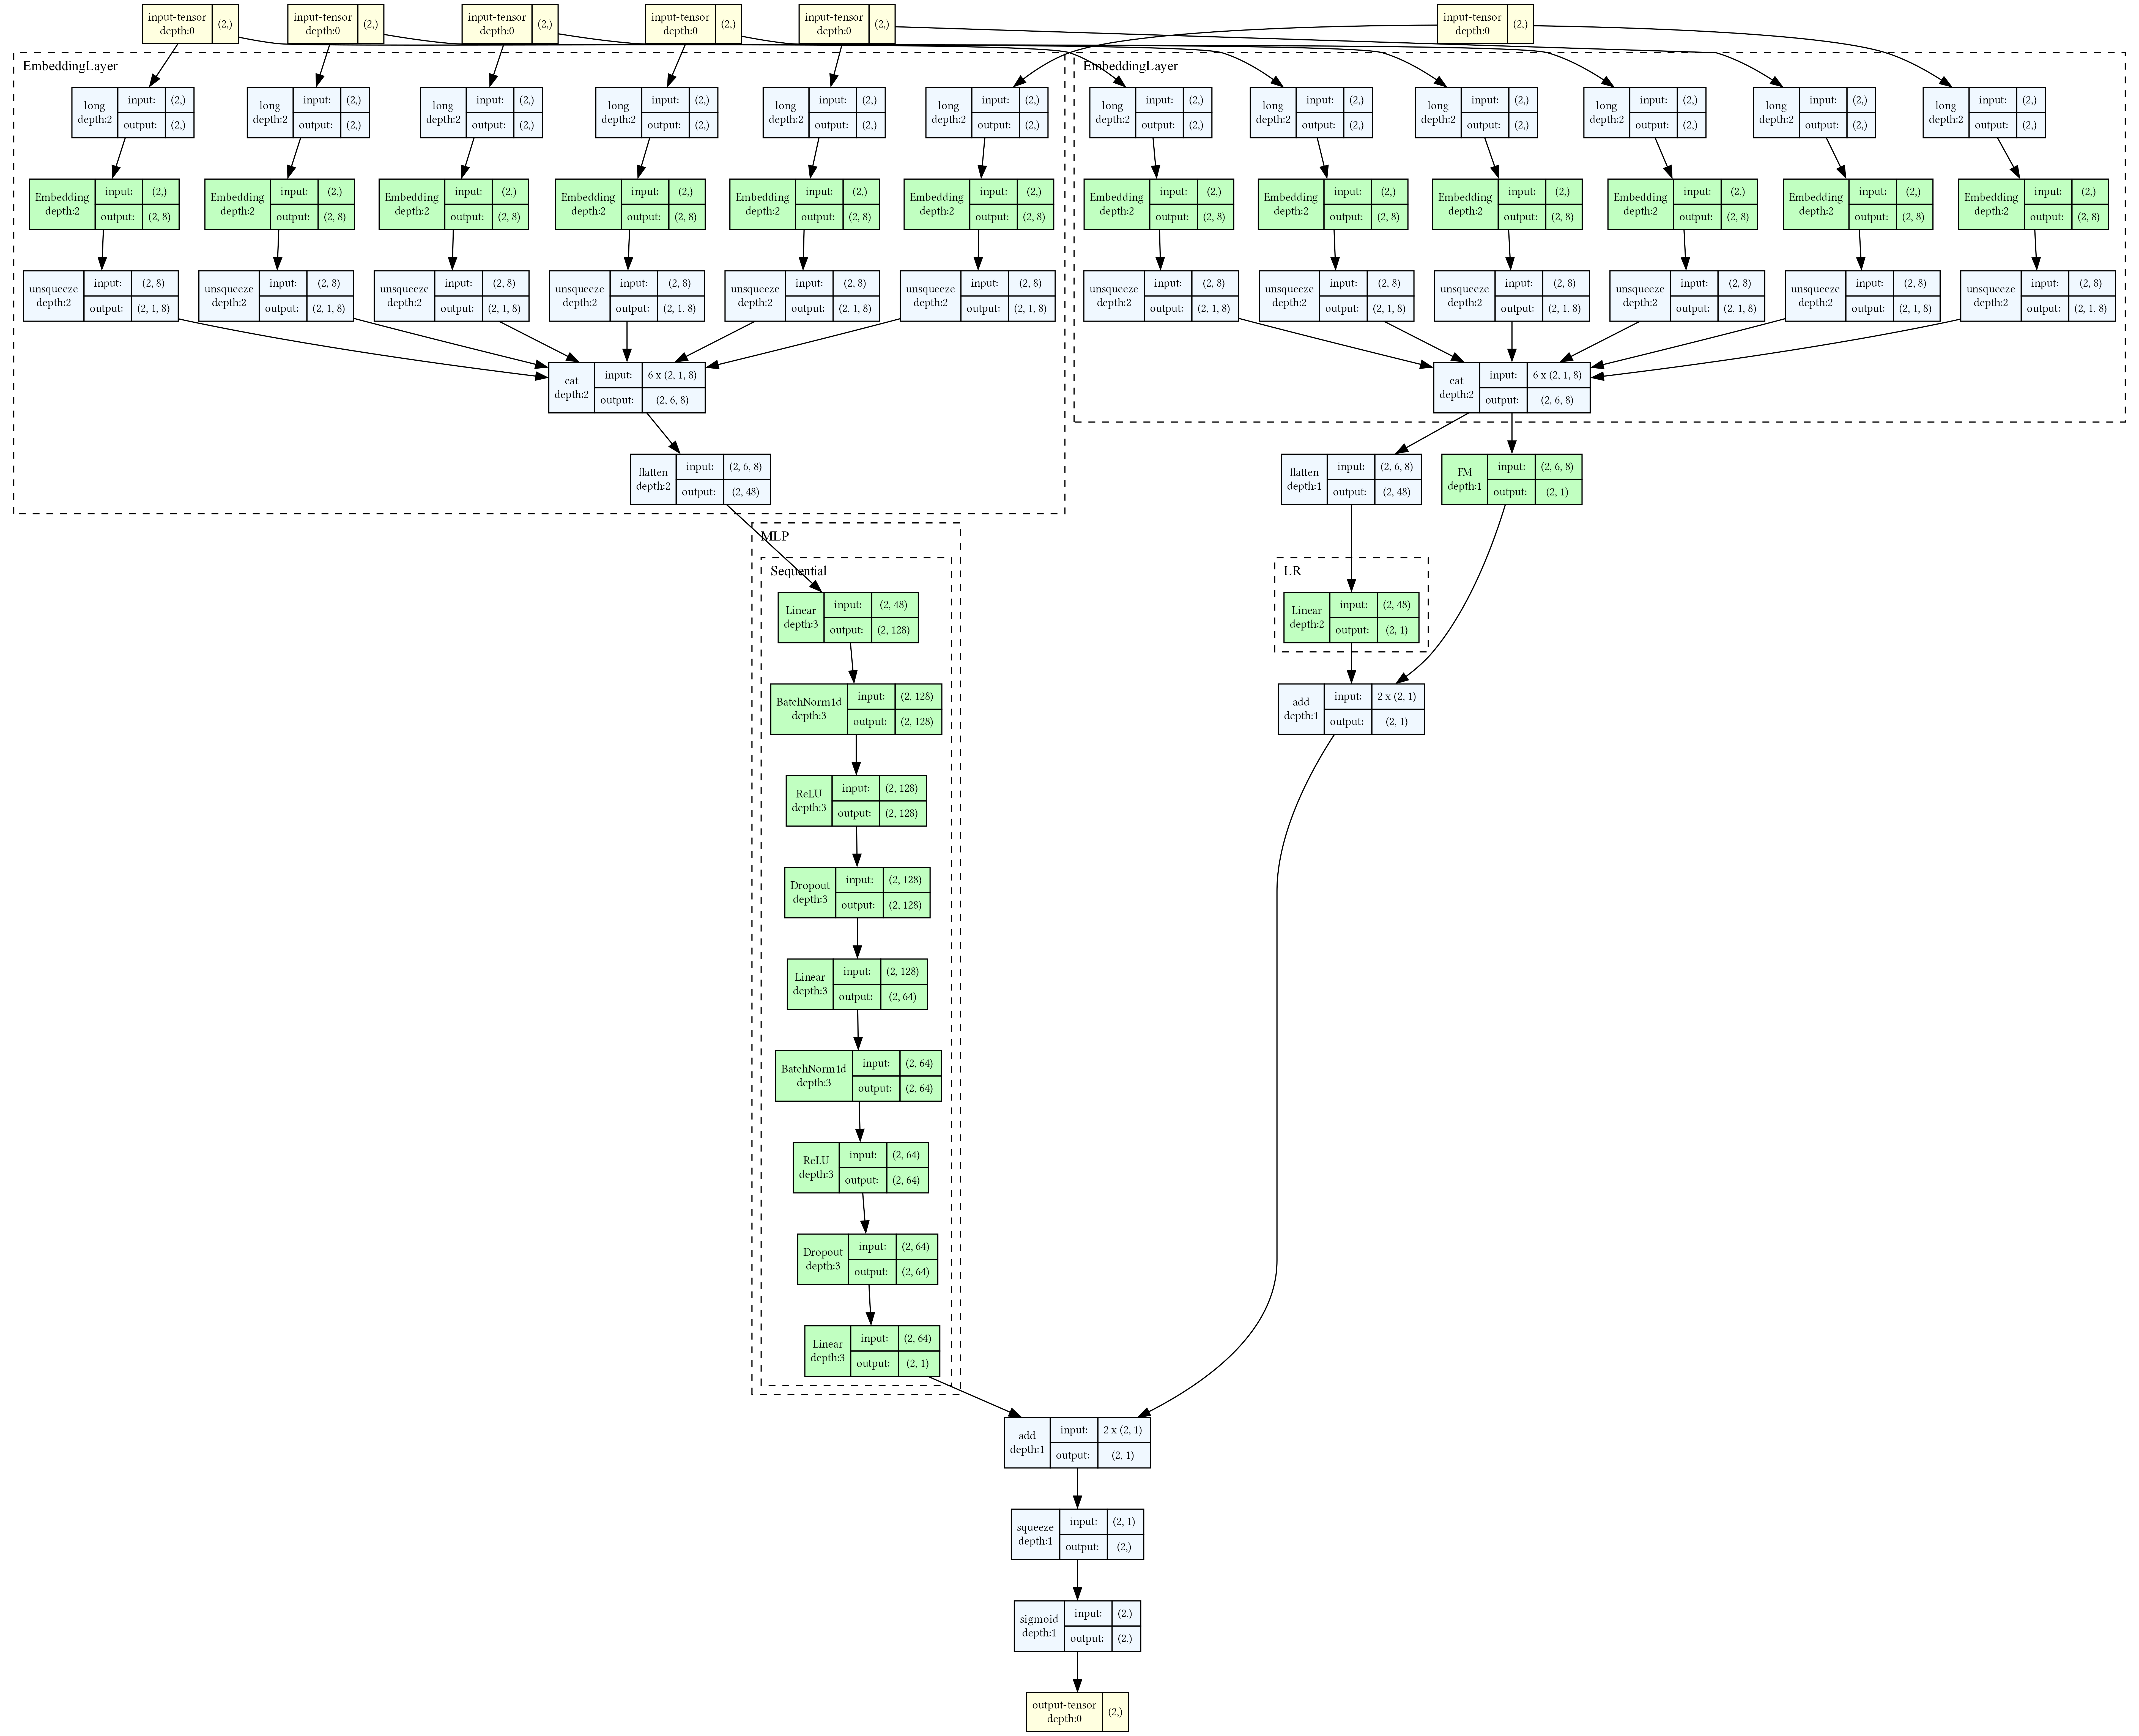

In [56]:
graph = visualize_model(model, depth=40)

以下是DeepFM模型的结构图：  
```text
DeepFM(
  (linear): LR(
    (fc): Linear(in_features=48, out_features=1, bias=True)
  )
  (fm): FM()
  (embedding): EmbeddingLayer(
    (embed_dict): ModuleDict(
      (user_id): Embedding(2, 8)
      (movie_id): Embedding(93, 8)
      (gender): Embedding(2, 8)
      (age): Embedding(2, 8)
      (occupation): Embedding(2, 8)
      (genres): Embedding(48, 8)
    )
    (input_mask): InputMask()
  )
  (mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=48, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
```
该模型一共分为四部分。   
1. EmbeddingLayer (嵌入层)   
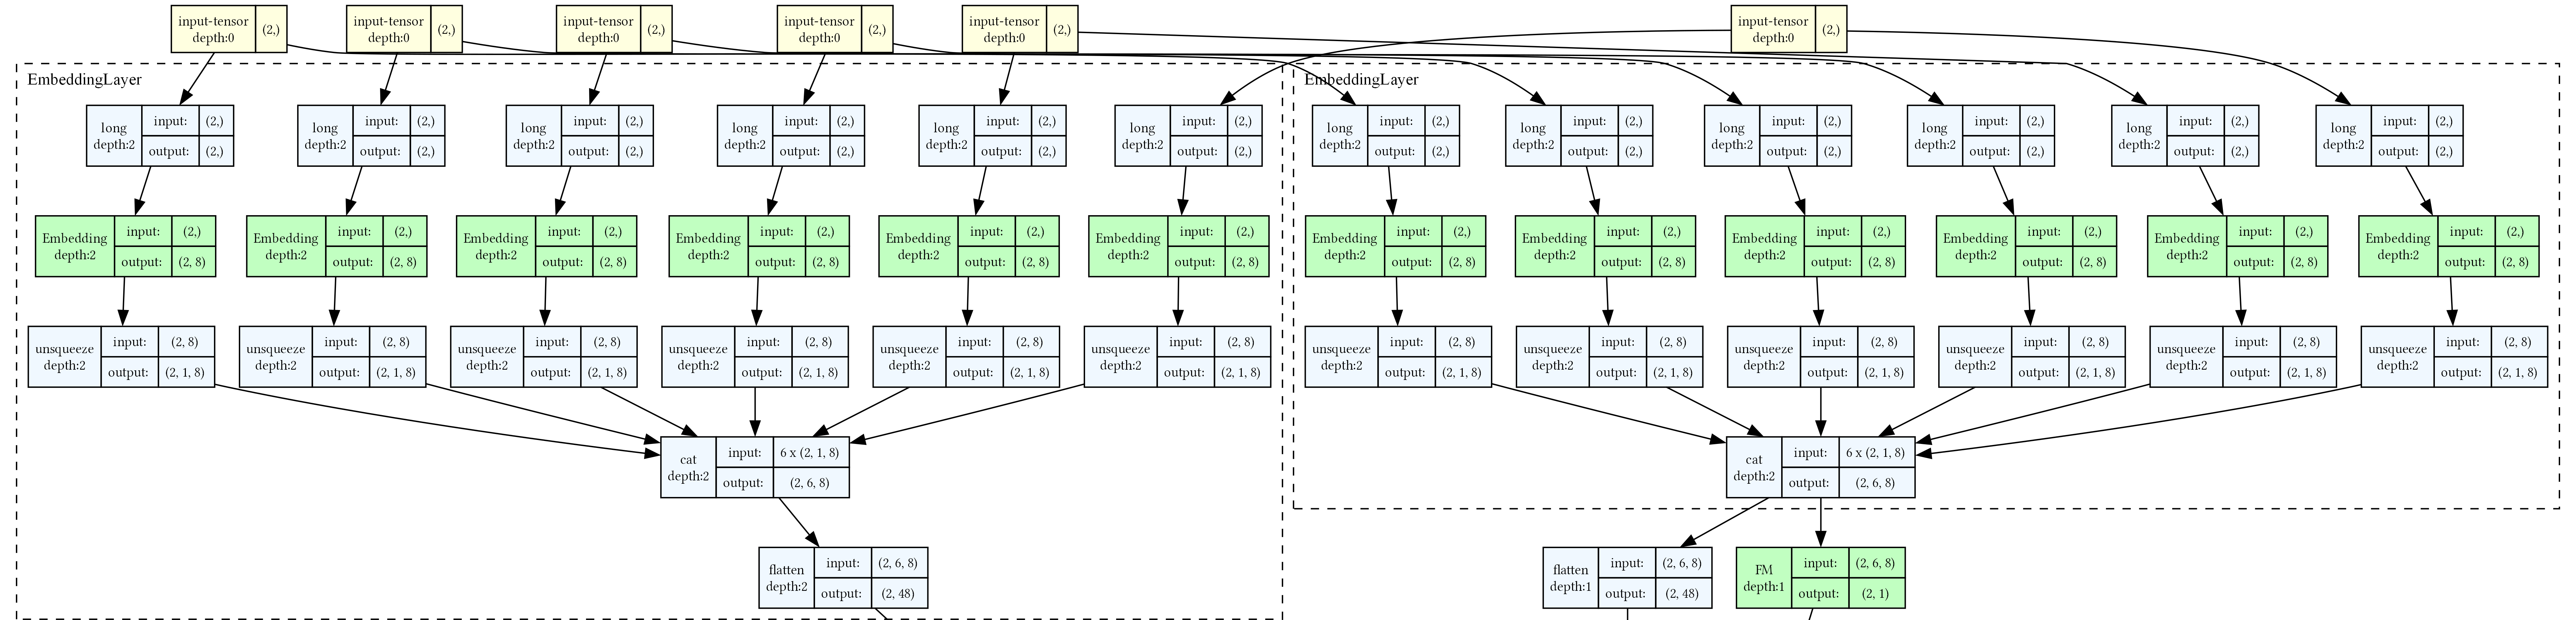
```text
  (embedding): EmbeddingLayer(
    (embed_dict): ModuleDict(
      (user_id): Embedding(2, 8)
      (movie_id): Embedding(93, 8)
      (gender): Embedding(2, 8)
      (age): Embedding(2, 8)
      (occupation): Embedding(2, 8)
      (genres): Embedding(48, 8)
    )
这个层的主要工作是将类别特征（如user_id, movie_id）从简单的数字索引（例如，用户A的ID是5）转换成有意义的、低维度的数值向量（称为“嵌入向量”或 "Embedding"）。
为什么需要转换？ 
原始的ID号，比如user_id 5 和 6，它们在数值上很接近，但并不代表这两个用户就相似。模型无法直接从这些ID号中学习到有用的信息。
如何转换？ 
EmbeddingLayer 像一个大型的查询表。
以 (user_id): Embedding(2, 8) 为例：
2：代表数据集中一共有2个独立的用户。这个数字来自于对user_id列进行LabelEncoder后的唯一值数量。
8：代表每个用户的嵌入向量的维度。也就是说，模型会用一个包含8个数字的向量来表示每一个用户。
最终输出：
当一条数据（例如，关于用户A看电影B的记录）进入模型时，这个层会为该记录中的每一个类别特征（user_id, movie_id, genres等）查找并输出其对应的8维向量。
```
2. LR (Linear Regression, 线性部分)  
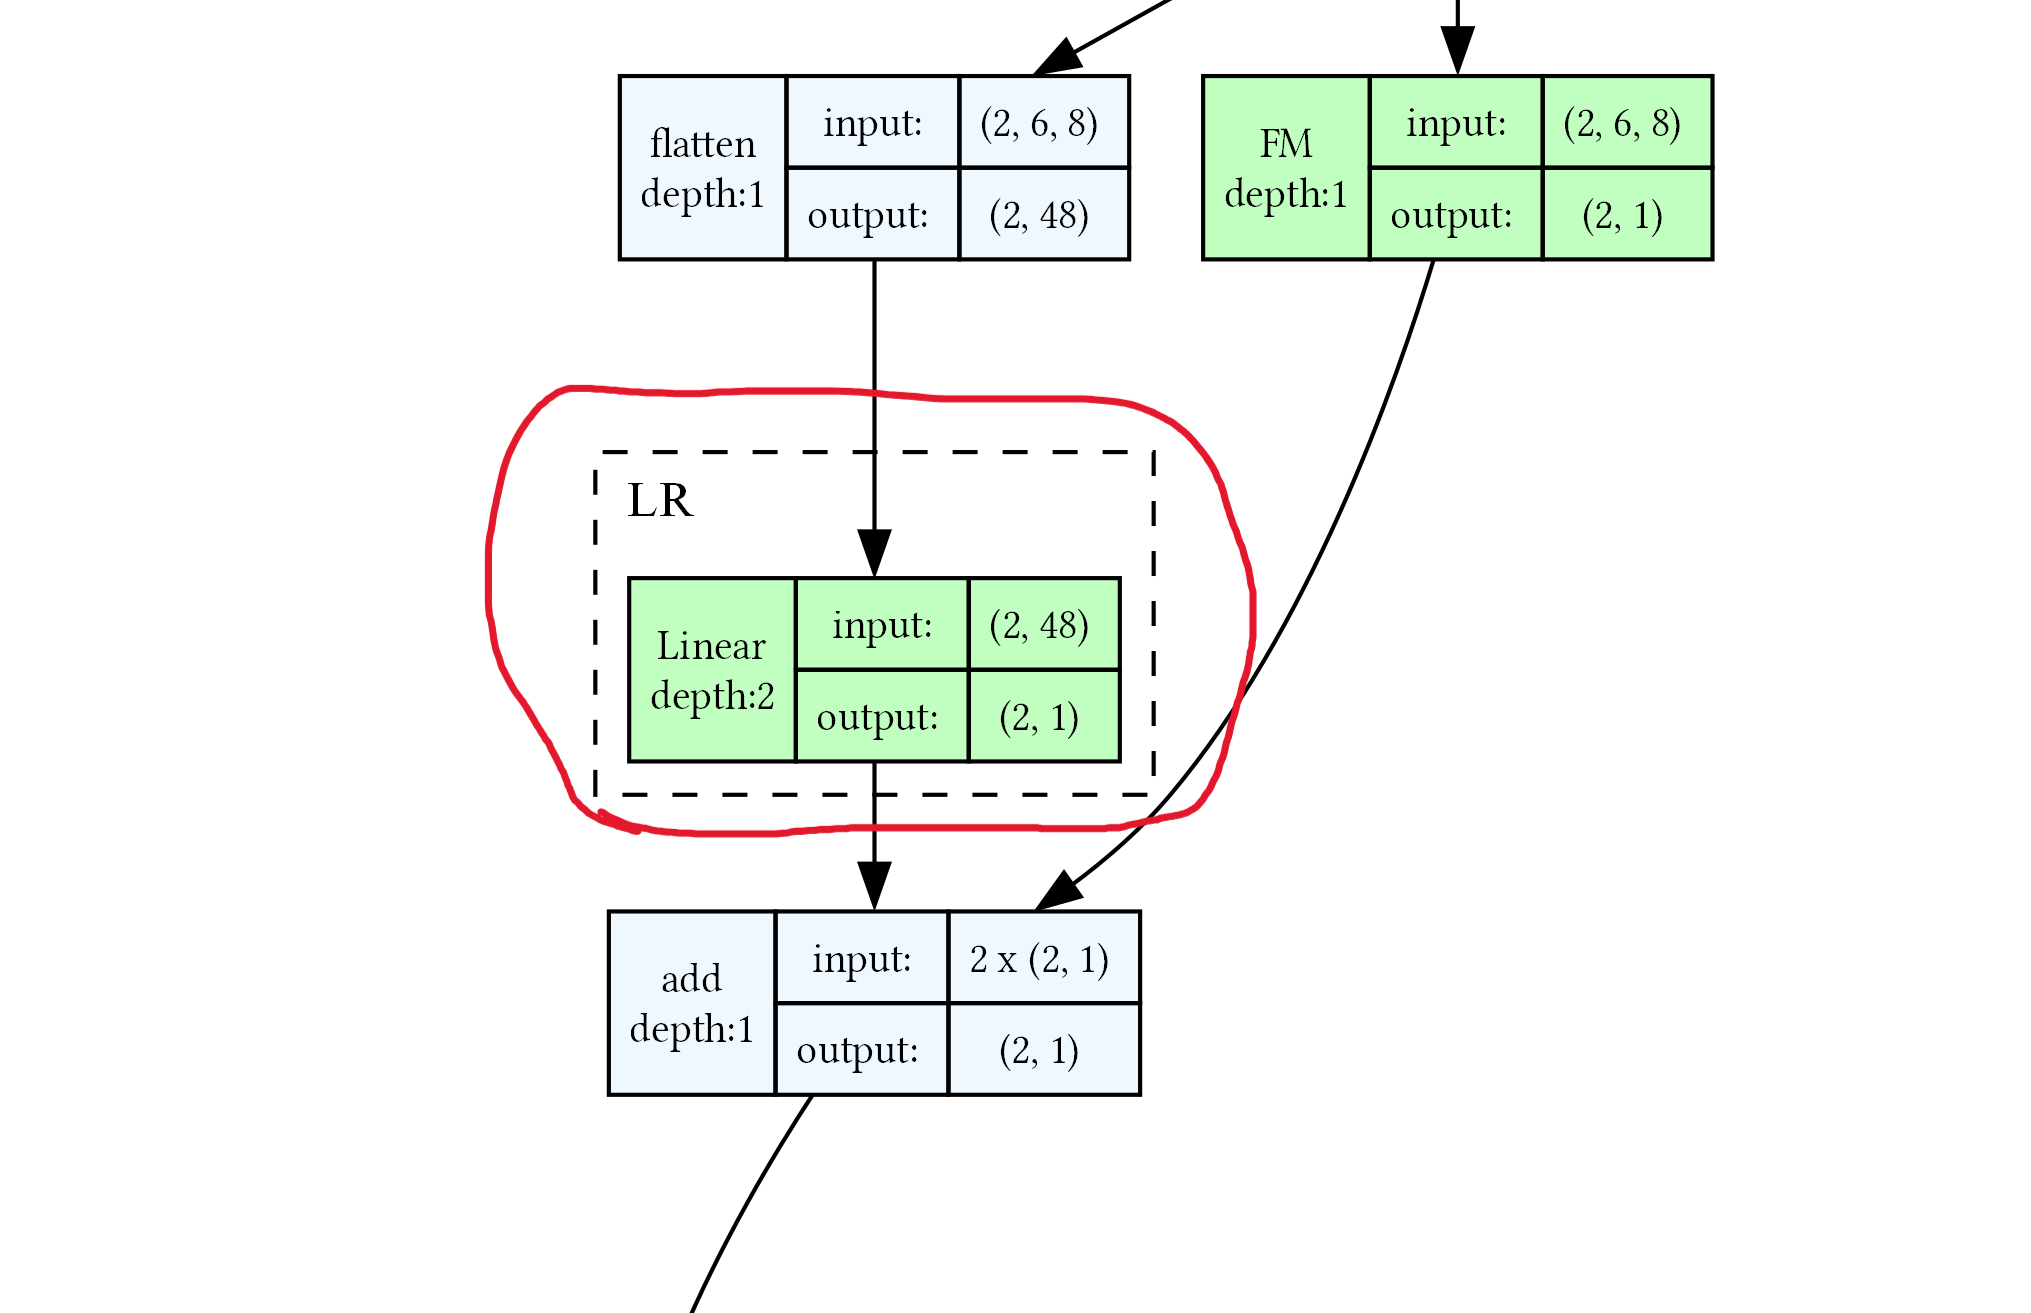
```text
  (linear): LR(
    (fc): Linear(in_features=48, out_features=1, bias=True)
  )
这个部分用来学习一阶特征 (First-Order Features) 的权重。简单来说，它衡量每个特征独立对最终结果的贡献度，而不考虑特征之间的任何交互。
它回答的问题是：某个电影本身是否就是热门电影？某个用户本身是不是一个活跃的高分用户？它只看单个特征，比如“电影类型是‘喜剧’”这个特征本身是否会增加用户“喜欢”的概率。
如何工作：它为每个特征学习一个权重，然后将它们加权求和，得出一个分数。这个分数代表了所有一阶特征的综合影响。
```
3. FM (Factorization Machine, 交互部分)

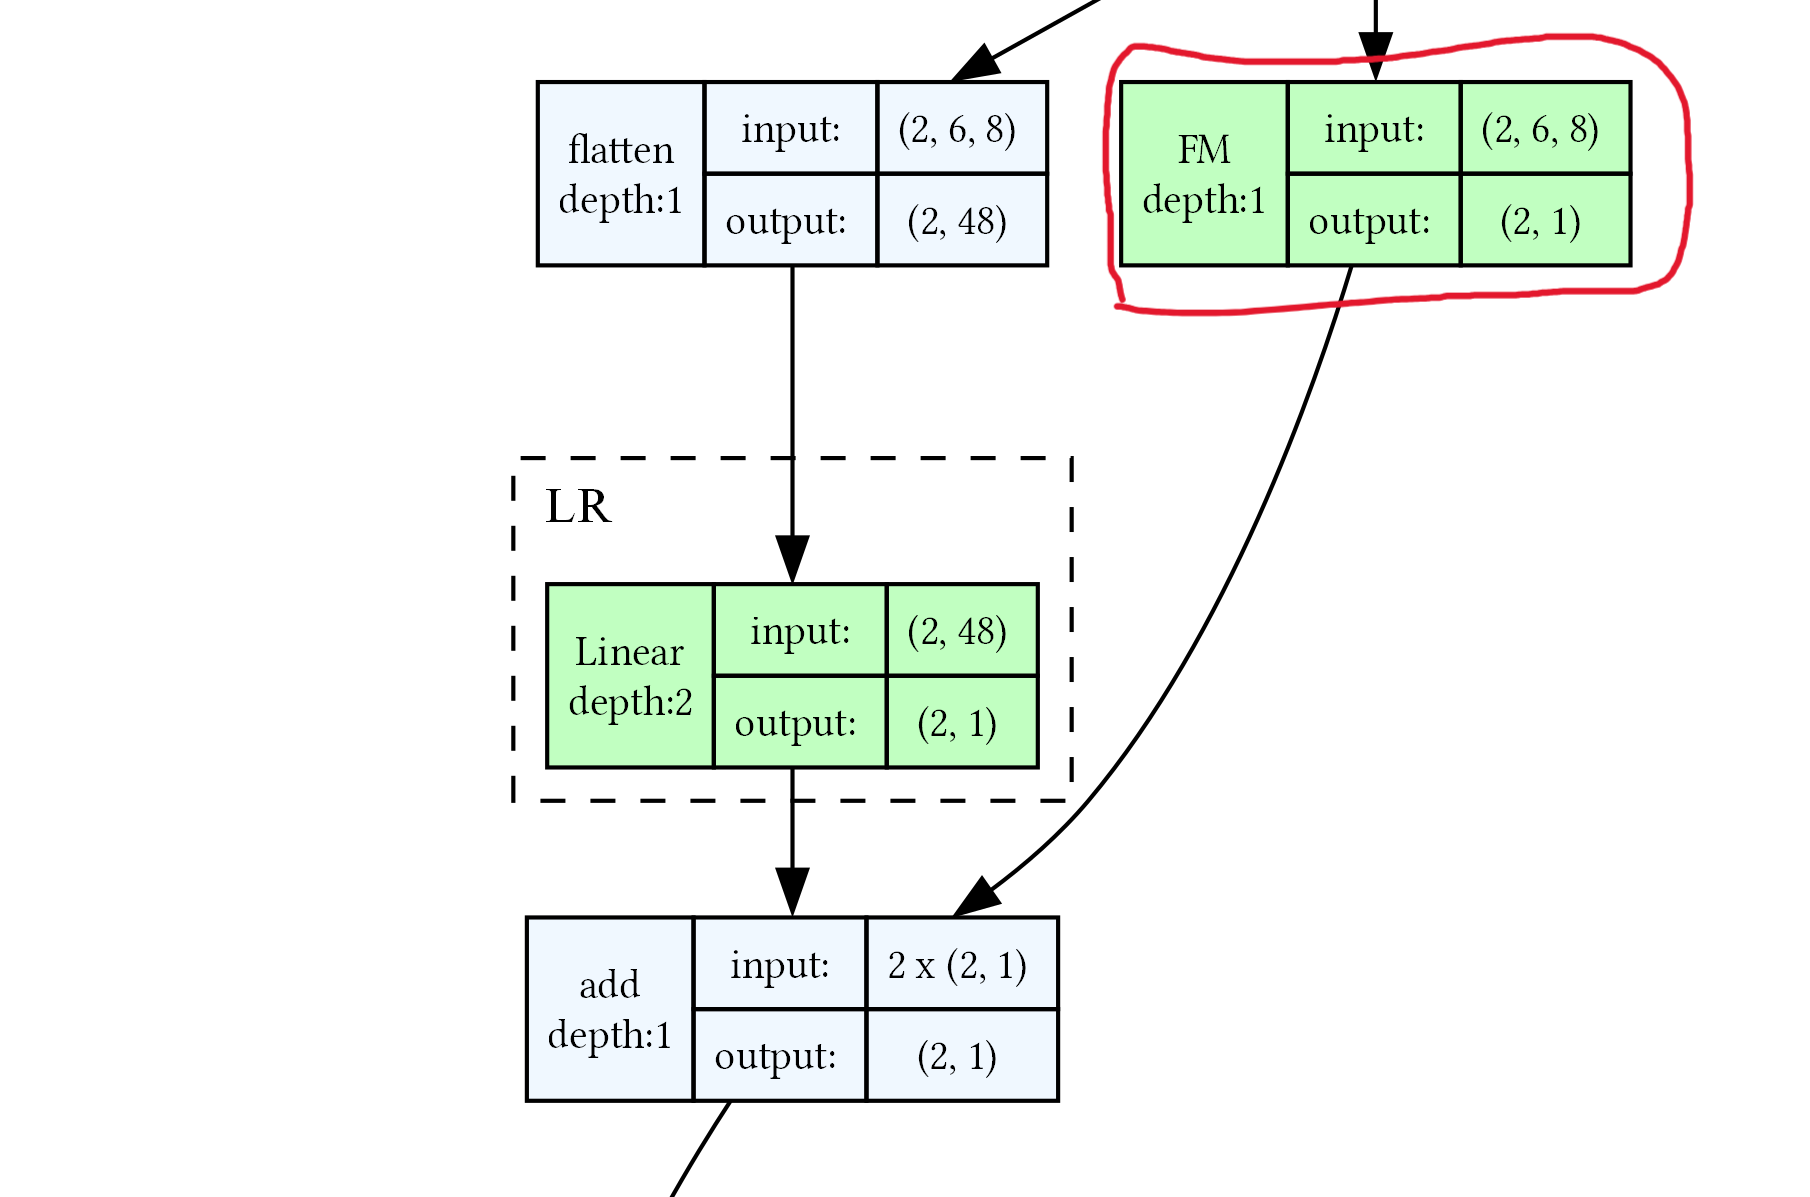
```text
(fm): FM()
这个部分用来学习二阶特征交叉 (Second-Order Feature Interactions)。它衡量任意两个特征组合在一起时的效果。
它回答的问题是：
“特定用户” 和 “特定电影类型” 组合在一起，会产生什么效果？
“特定年龄段” 和 “特定职业” 的用户组合在一起，对电影偏好有什么影响？
如何工作：它利用了第一步中生成的嵌入向量。通过计算任意两个特征的嵌入向量的内积（Dot Product），来衡量这两个特征的交互强度。例如，它会计算 user_id 的嵌入向量和 genres 的嵌入向量的内积。如果一个用户和一个电影类型的嵌入向量在方向上很相似，它们的内积就会很大，这会增加最终预测为“喜欢”的概率。
```
4. Deep (MLP, 深度部分)

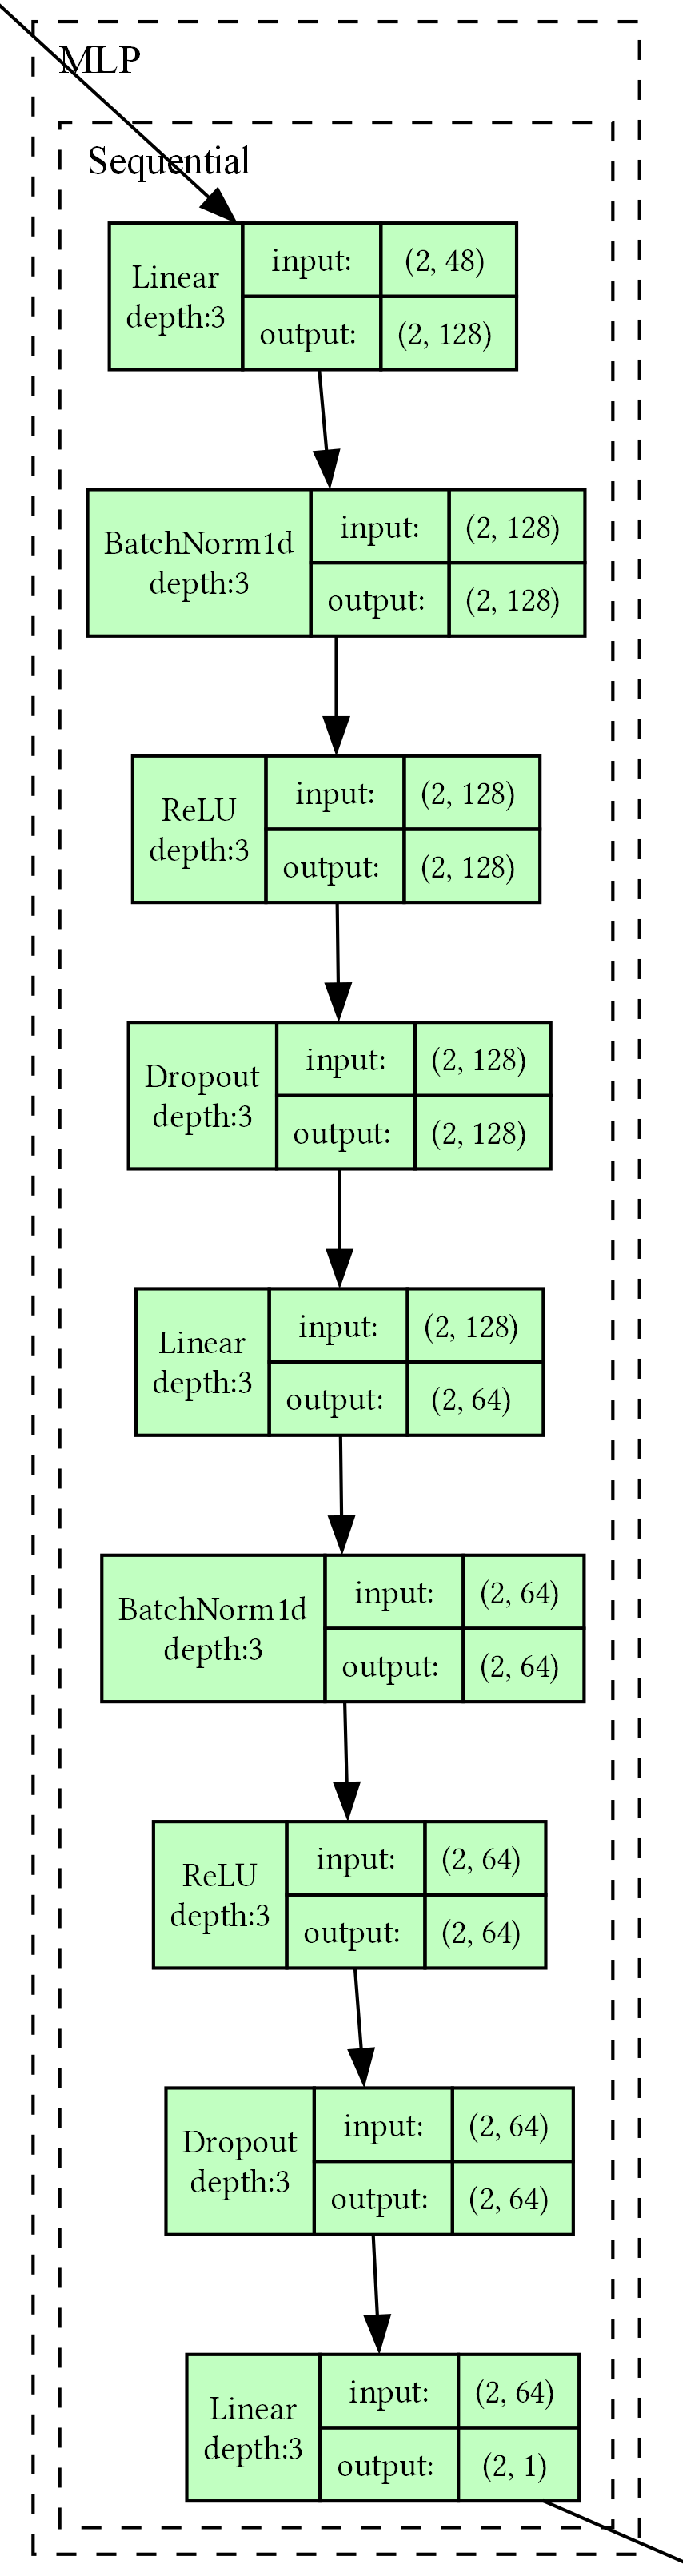
```text
  (mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=48, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=1, bias=True)
    )
  )
这个部分通过多层非线性变换，自动学习高阶的、更复杂的特征交叉。
它回答的问题是：是否存在一些难以手动发现的复杂模式？例如，“年龄在18-24岁（age）的男性（gender）程序员（occupation）是否对科幻（genres）电影有特别强的偏好？” 这种涉及三个或更多特征的复杂关系，就是高阶交叉。
如何工作：
输入：它将所有类别特征的嵌入向量**拼接（Concatenate）**在一起。因为我们有6个特征（user_id, movie_id, gender, age, occupation, genres），每个特征的嵌入向量维度是8，所以拼接后的总维度是 6 * 8 = 48。这就是第一层 Linear(in_features=48, ...) 中 in_features=48 的由来。
处理：这个48维的向量会经过一系列的线性层（Linear）、激活函数（ReLU）和正则化层（BatchNorm1d, Dropout）。这个过程让模型可以捕捉到特征之间非常复杂和非线性的关系。
输出：最后，它也输出一个单一的数值，代表从高阶特征交叉中学习到的分数。
```
```text
最后，模型将三部分的预测分数求和，得到了最终分数。
这个最终分数会再通过一个 Sigmoid 函数，转换成一个介于 0 和 1 之间的概率值，表示用户“喜欢”这部电影的可能性。
Linear 部分 提供了基础的、独立的特征贡献。
FM 部分 精准地捕捉了成对特征之间的交互。
MLP 部分 自动探索了所有特征之间潜在的、更深层次的复杂关系。
这种结构让DeepFM既能“记住”简单的模式（像Wide & Deep模型中的Wide部分），又能“泛化”到复杂的、未见过的模式（像Deep部分），因此在CTR预估等任务中表现非常出色。
```
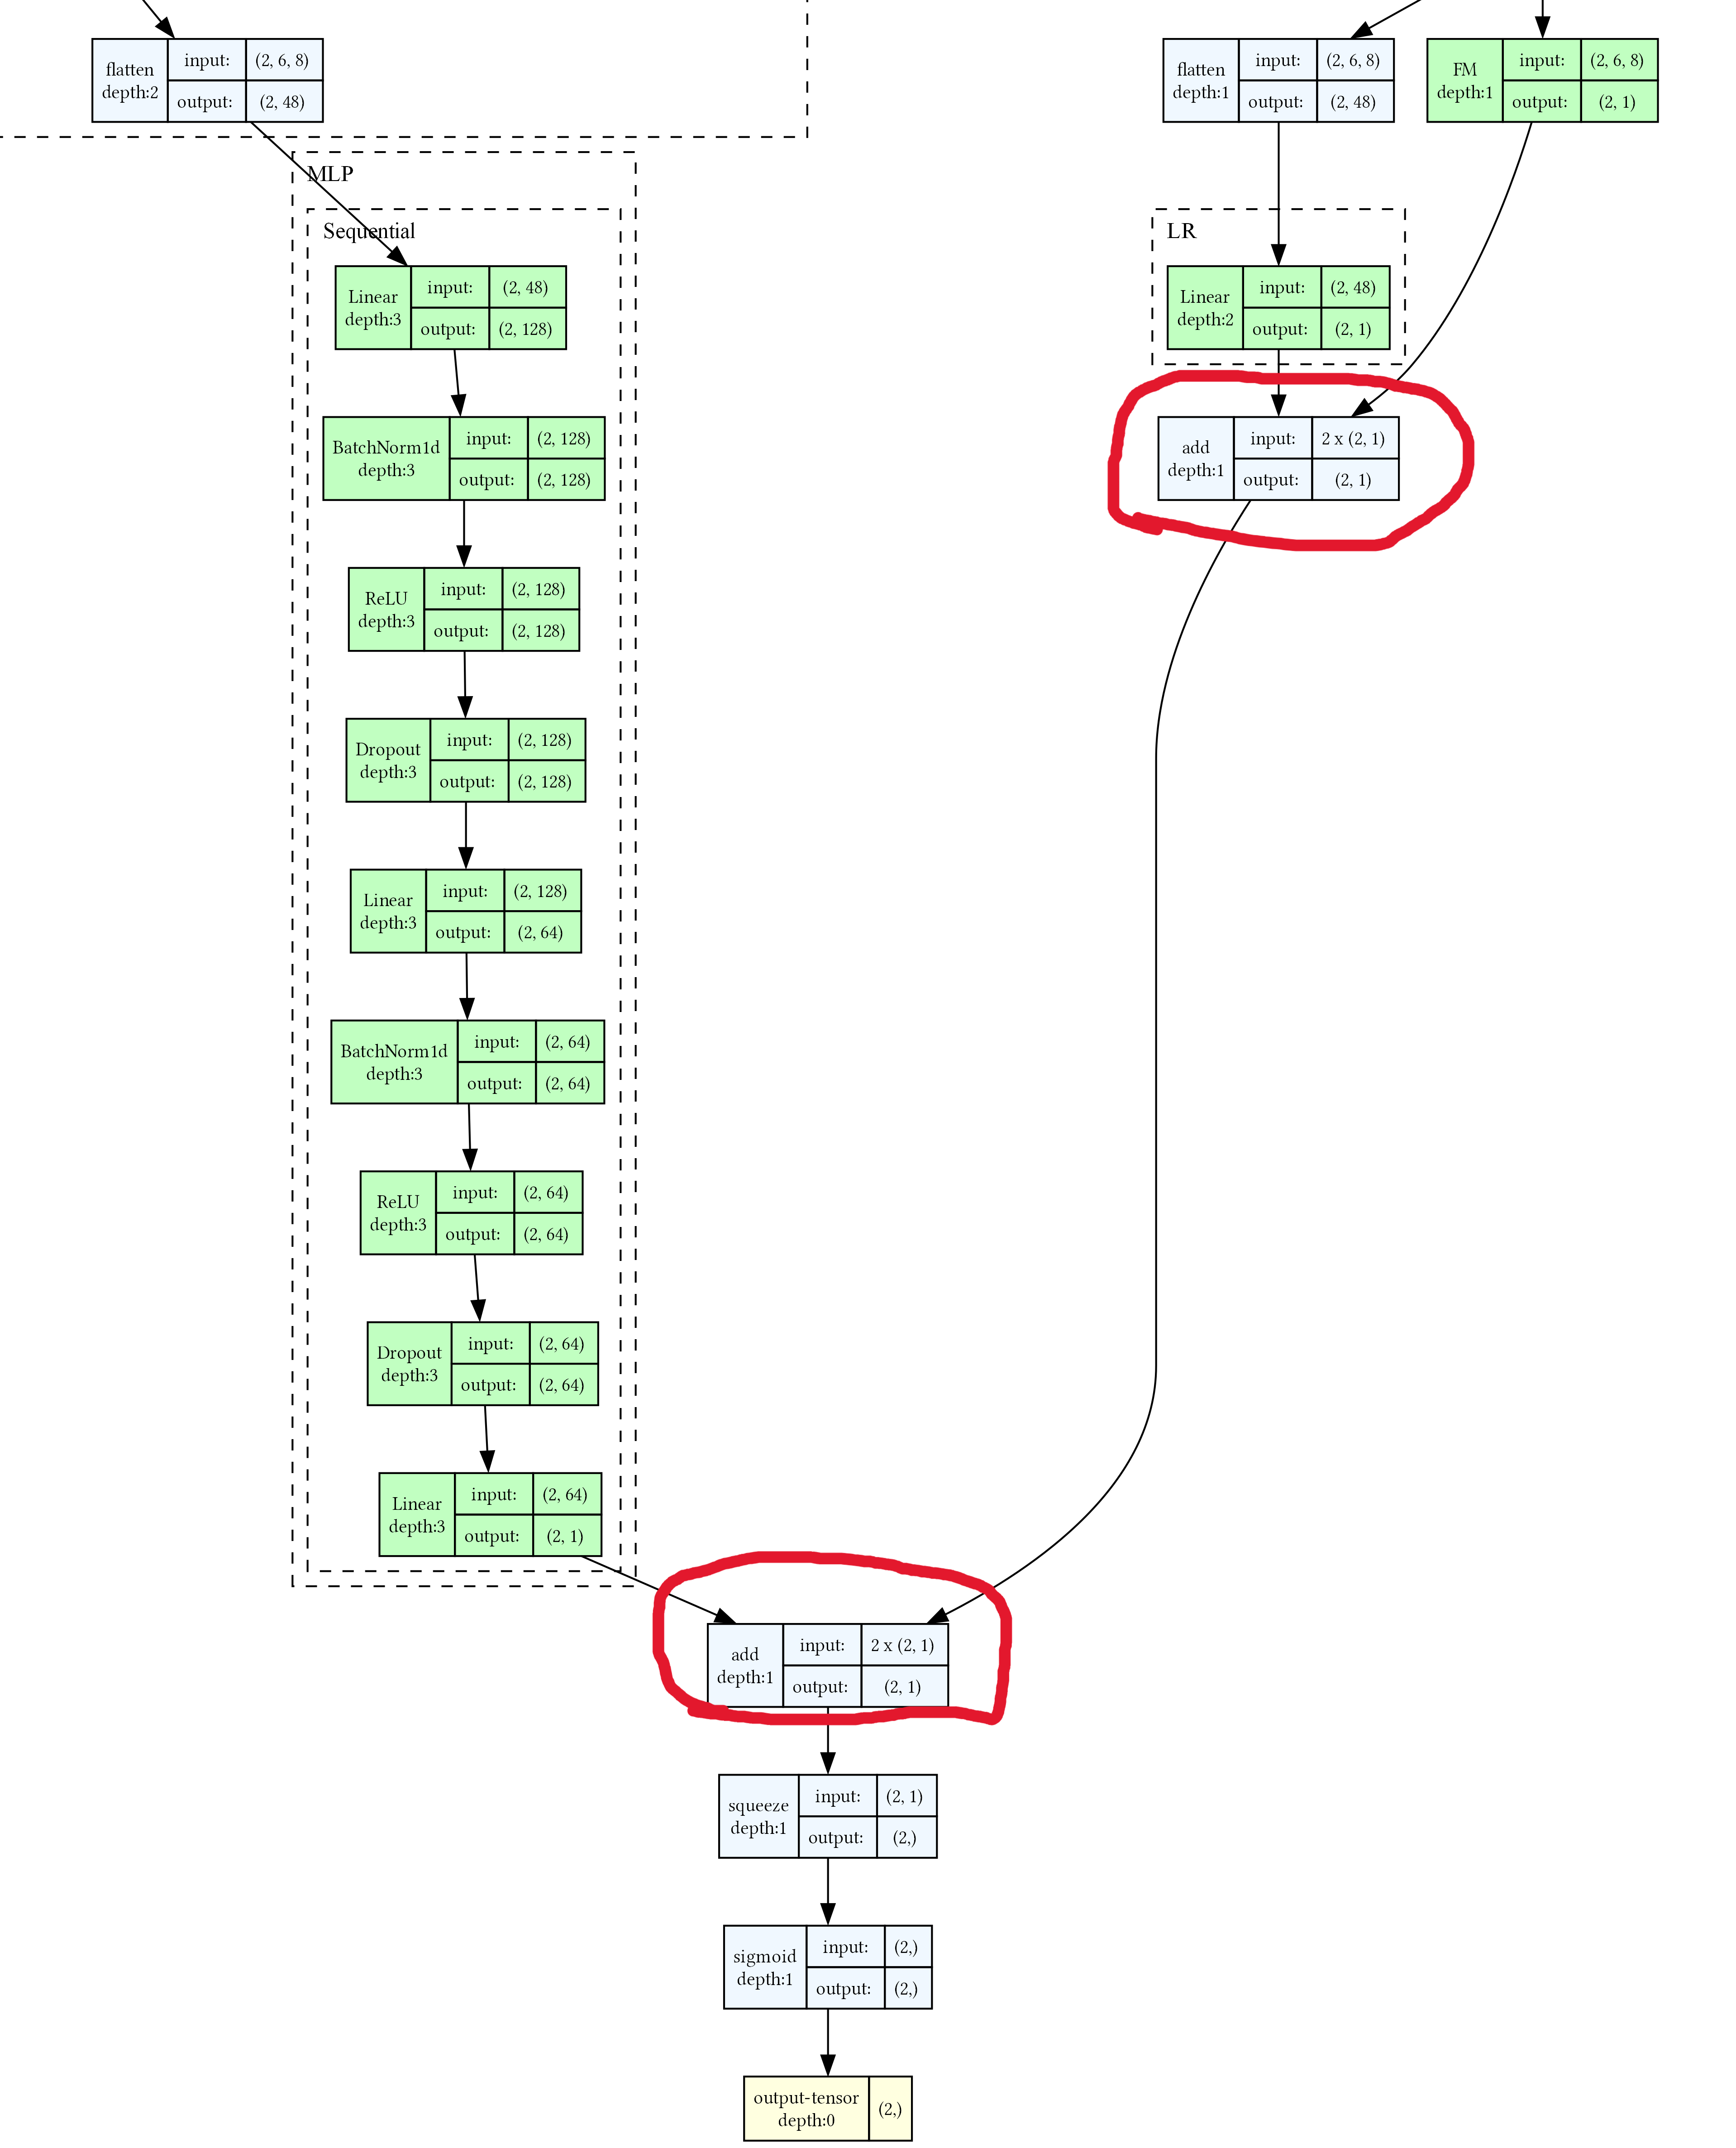
**下段代码作用**：展示模型结构。


In [71]:
print(model)

DeepFM(
  (linear): LR(
    (fc): Linear(in_features=48, out_features=1, bias=True)
  )
  (fm): FM()
  (embedding): EmbeddingLayer(
    (embed_dict): ModuleDict(
      (user_id): Embedding(2, 8)
      (movie_id): Embedding(93, 8)
      (gender): Embedding(2, 8)
      (age): Embedding(2, 8)
      (occupation): Embedding(2, 8)
      (genres): Embedding(48, 8)
    )
    (input_mask): InputMask()
  )
  (mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=48, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
